# WordPiece Tokenizer Statistics Report

Reads `tokenization_stats.json` produced by `scripts/calc_tokenization_stats.py` and renders all statistics: split-level metrics, alarms, top-token lists, and every diagnostic distribution across the vocab_size grid.

Reusable across experiments - only the `STATS_JSON_PATH` in the next cell needs to change.

In [1]:
# parameters
STATS_JSON_PATH = "../artifacts/tokenizers_1M/stats/tokenization_stats.json"
TOP_K_DISPLAY = 15  # how many entries to show per top-token list in this notebook

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 200)

stats_path = Path(STATS_JSON_PATH)
results = json.loads(stats_path.read_text(encoding="utf-8"))

vocab_sizes = sorted(int(vs) for vs in results["per_vocab_size"].keys())
per_vocab_size = results["per_vocab_size"]
split_names = ("train", "val", "test")
split_colors = {"train": "tab:red", "val": "tab:blue", "test": "tab:orange"}

print(f"Loaded {stats_path}")
print(f"vocab_size grid: {vocab_sizes}")
if results.get("vocab_sizes_skipped_missing_tokenizer"):
    print(f"WARNING - skipped (tokenizer.json missing): {results['vocab_sizes_skipped_missing_tokenizer']}")

Loaded ..\artifacts\tokenizers_1M\stats\tokenization_stats.json
vocab_size grid: [100, 1000, 10000, 50000, 100000, 200000, 300000]


## 1. Split-level summary table

In [3]:
rows = []
for vocab_size in vocab_sizes:
    entry = per_vocab_size[str(vocab_size)]
    for split_name in split_names:
        s = entry["splits"][split_name]
        rows.append({
            "vocab_size": vocab_size,
            "vocab_size_actual": entry["vocab_size_actual"],
            "split": split_name,
            "mean_num_tokens": s["mean_num_tokens"],
            "median_num_tokens": s["median_num_tokens"],
            "min_num_tokens": s["min_num_tokens"],
            "max_num_tokens": s["max_num_tokens"],
            "p95_num_tokens": s["p95_num_tokens"],
            "compression_ratio": s["compression_ratio"],
            "unk_token_fraction": s["unk_token_fraction"],
            "fraction_1_token": s["fraction_encoded_as_1_token"],
            "fraction_le_3_tokens": s["fraction_encoded_as_3_tokens_or_less"],
        })

summary_df = pd.DataFrame(rows)


def highlight_train_alarms(row):
    if row["split"] != "train":
        return [""] * len(row)
    alarms = per_vocab_size[str(row["vocab_size"])]["alarms"]
    any_triggered = any(a["triggered"] for a in alarms.values())
    return ["background-color: #ffcccc" if any_triggered else ""] * len(row)


summary_df.style.apply(highlight_train_alarms, axis=1).format(
    {
        "mean_num_tokens": "{:.2f}", "median_num_tokens": "{:.1f}", "p95_num_tokens": "{:.1f}",
        "compression_ratio": "{:.3f}", "unk_token_fraction": "{:.4%}",
        "fraction_1_token": "{:.2%}", "fraction_le_3_tokens": "{:.2%}",
    }
)

,vocab_size,vocab_size_actual,split,mean_num_tokens,median_num_tokens,min_num_tokens,max_num_tokens,p95_num_tokens,compression_ratio,unk_token_fraction,fraction_1_token,fraction_le_3_tokens
0,100,100,train,7.25,7.0,2,20,10.0,0.486,0.0000%,0.00%,0.05%
1,100,100,val,7.25,7.0,3,20,10.0,0.486,0.0000%,0.00%,0.04%
2,100,100,test,7.25,7.0,2,19,10.0,0.486,0.0000%,0.00%,0.04%
3,1000,1000,train,4.14,4.0,2,12,6.0,0.278,0.0000%,0.00%,22.84%
4,1000,1000,val,4.14,4.0,2,11,6.0,0.277,0.0000%,0.00%,22.98%
5,1000,1000,test,4.14,4.0,2,13,6.0,0.278,0.0000%,0.00%,22.82%
6,10000,10000,train,3.06,3.0,2,11,4.0,0.205,0.0000%,0.00%,76.44%
7,10000,10000,val,3.07,3.0,2,9,4.0,0.206,0.0000%,0.00%,76.13%
8,10000,10000,test,3.07,3.0,2,9,4.0,0.206,0.0000%,0.00%,75.94%
9,50000,50000,train,2.53,2.0,1,10,4.0,0.170,0.0000%,0.00%,91.44%


Highlighted train rows have at least one triggered alarm (vocab_size_too_large / tokenizer_misconfigured / insufficient_compression_benefit) - see section 3.

## 2. Diagnostic plots

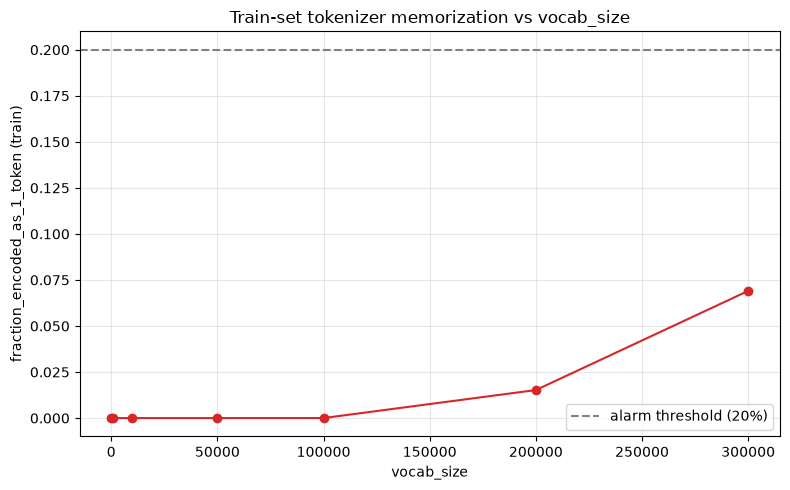

In [4]:
def plot_train_memorization():
    values = [per_vocab_size[str(vs)]["splits"]["train"]["fraction_encoded_as_1_token"] for vs in vocab_sizes]
    threshold = next(iter(per_vocab_size.values()))["alarms"]["vocab_size_too_large"]["threshold"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(vocab_sizes, values, marker="o", color="tab:red")
    ax.axhline(threshold, color="gray", linestyle="--", label=f"alarm threshold ({threshold:.0%})")
    ax.set_xlabel("vocab_size"); ax.set_ylabel("fraction_encoded_as_1_token (train)")
    ax.set_title("Train-set tokenizer memorization vs vocab_size")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


plot_train_memorization()

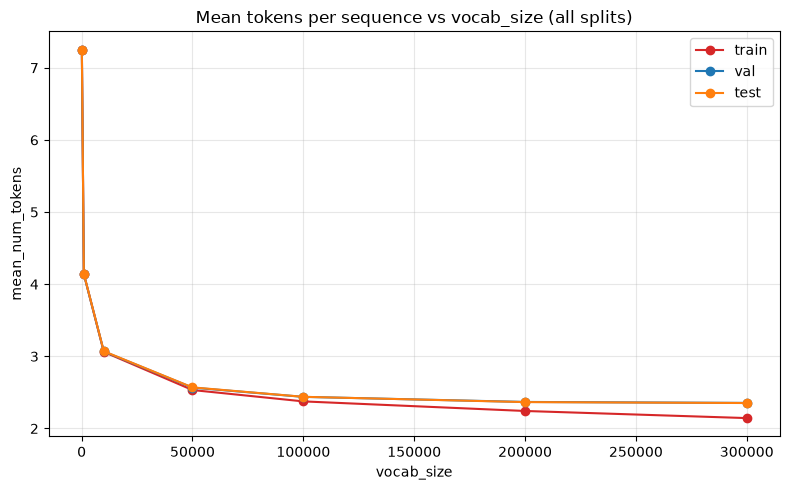

In [5]:
def plot_metric_vs_vocab_size(metric_key, ylabel, title, hline=None, hline_label=""):
    fig, ax = plt.subplots(figsize=(8, 5))
    for split_name in split_names:
        values = [per_vocab_size[str(vs)]["splits"][split_name][metric_key] for vs in vocab_sizes]
        ax.plot(vocab_sizes, values, marker="o", label=split_name, color=split_colors[split_name])
    if hline is not None:
        ax.axhline(hline, color="gray", linestyle="--", label=hline_label)
    ax.set_xlabel("vocab_size"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


plot_metric_vs_vocab_size("mean_num_tokens", "mean_num_tokens", "Mean tokens per sequence vs vocab_size (all splits)")

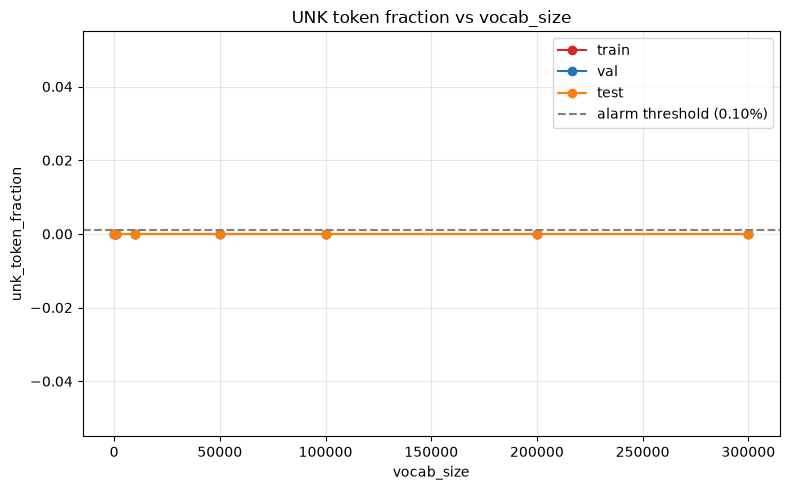

In [6]:
unk_threshold = next(iter(per_vocab_size.values()))["alarms"]["tokenizer_misconfigured"]["threshold"]
plot_metric_vs_vocab_size(
    "unk_token_fraction", "unk_token_fraction", "UNK token fraction vs vocab_size",
    hline=unk_threshold, hline_label=f"alarm threshold ({unk_threshold:.2%})",
)

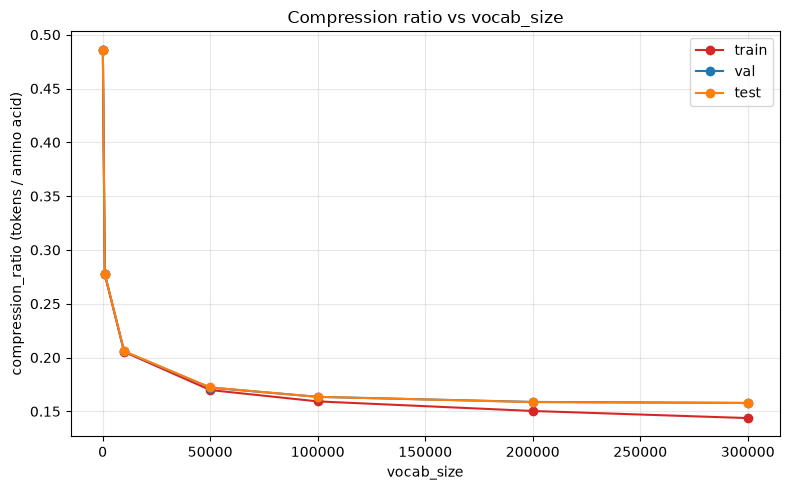

In [7]:
plot_metric_vs_vocab_size("compression_ratio", "compression_ratio (tokens / amino acid)", "Compression ratio vs vocab_size")

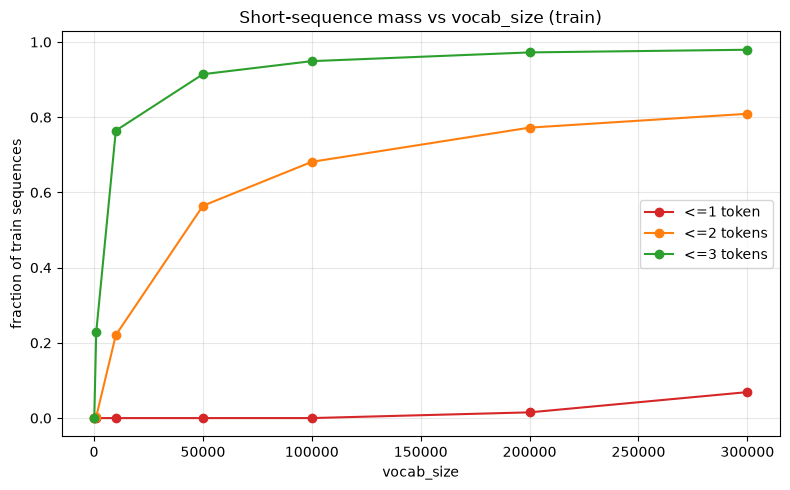

In [8]:
def plot_fraction_short_sequences():
    metric_keys = ("fraction_encoded_as_1_token", "fraction_encoded_as_2_tokens_or_less", "fraction_encoded_as_3_tokens_or_less")
    labels = ("<=1 token", "<=2 tokens", "<=3 tokens")
    colors = ("tab:red", "tab:orange", "tab:green")
    fig, ax = plt.subplots(figsize=(8, 5))
    for metric_key, label, color in zip(metric_keys, labels, colors):
        values = [per_vocab_size[str(vs)]["splits"]["train"][metric_key] for vs in vocab_sizes]
        ax.plot(vocab_sizes, values, marker="o", label=label, color=color)
    ax.set_xlabel("vocab_size"); ax.set_ylabel("fraction of train sequences")
    ax.set_title("Short-sequence mass vs vocab_size (train)")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()


plot_fraction_short_sequences()

### Token count distribution per sequence (train split)

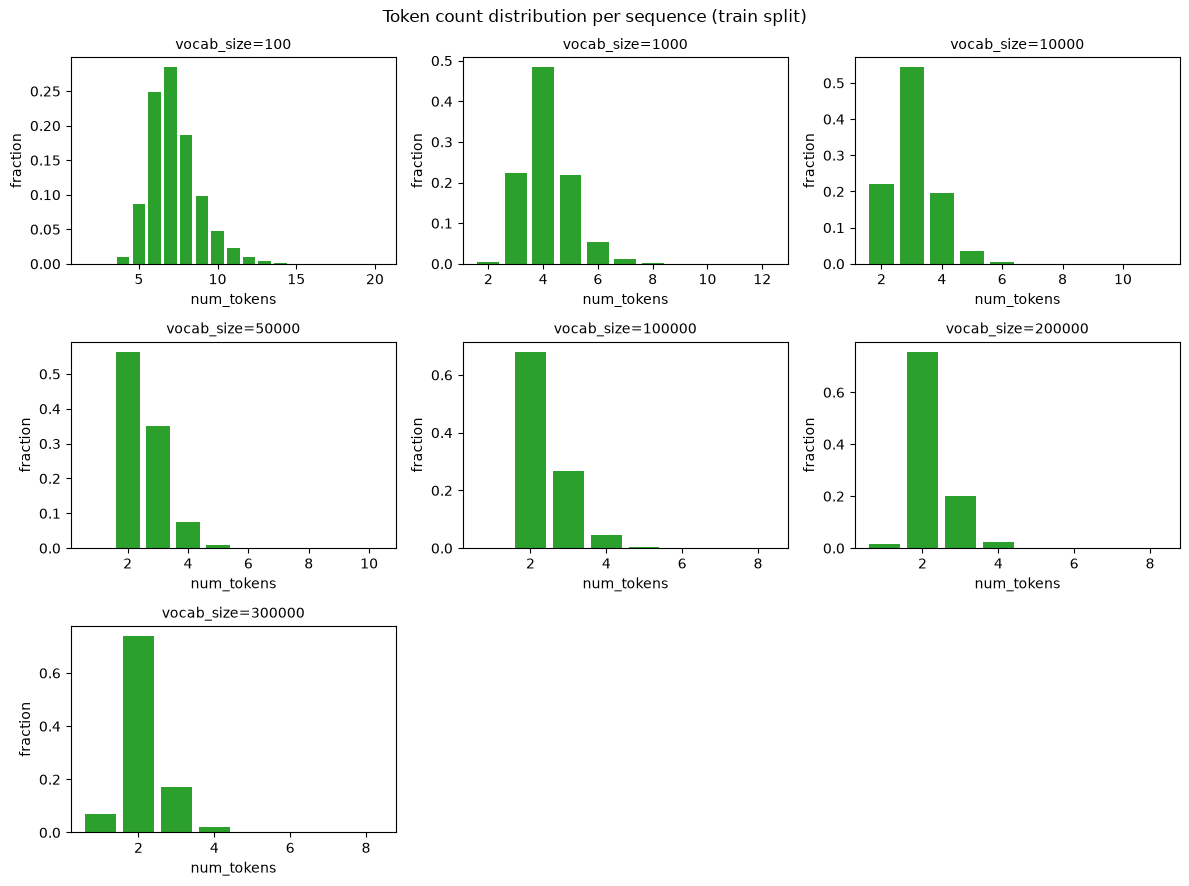

In [9]:
import math


def plot_histogram_grid(histogram_key, xlabel, suptitle, get_histogram):
    ncols = 3
    nrows = math.ceil(len(vocab_sizes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)
    for idx, vocab_size in enumerate(vocab_sizes):
        ax = axes[idx // ncols][idx % ncols]
        histogram = get_histogram(vocab_size)
        keys = sorted(int(k) for k in histogram.keys())
        counts = [histogram[str(k)] for k in keys]
        total = sum(counts)
        fractions = [c / total for c in counts]
        ax.bar(keys, fractions, color="tab:green")
        ax.set_title(f"vocab_size={vocab_size}", fontsize=10)
        ax.set_xlabel(xlabel); ax.set_ylabel("fraction")
    for idx in range(len(vocab_sizes), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")
    fig.suptitle(suptitle); fig.tight_layout(); plt.show()


plot_histogram_grid(
    "token_count_histogram", "num_tokens", "Token count distribution per sequence (train split)",
    get_histogram=lambda vs: per_vocab_size[str(vs)]["splits"]["train"]["token_count_histogram"],
)

### Token length distribution, frequency-weighted (train usage)

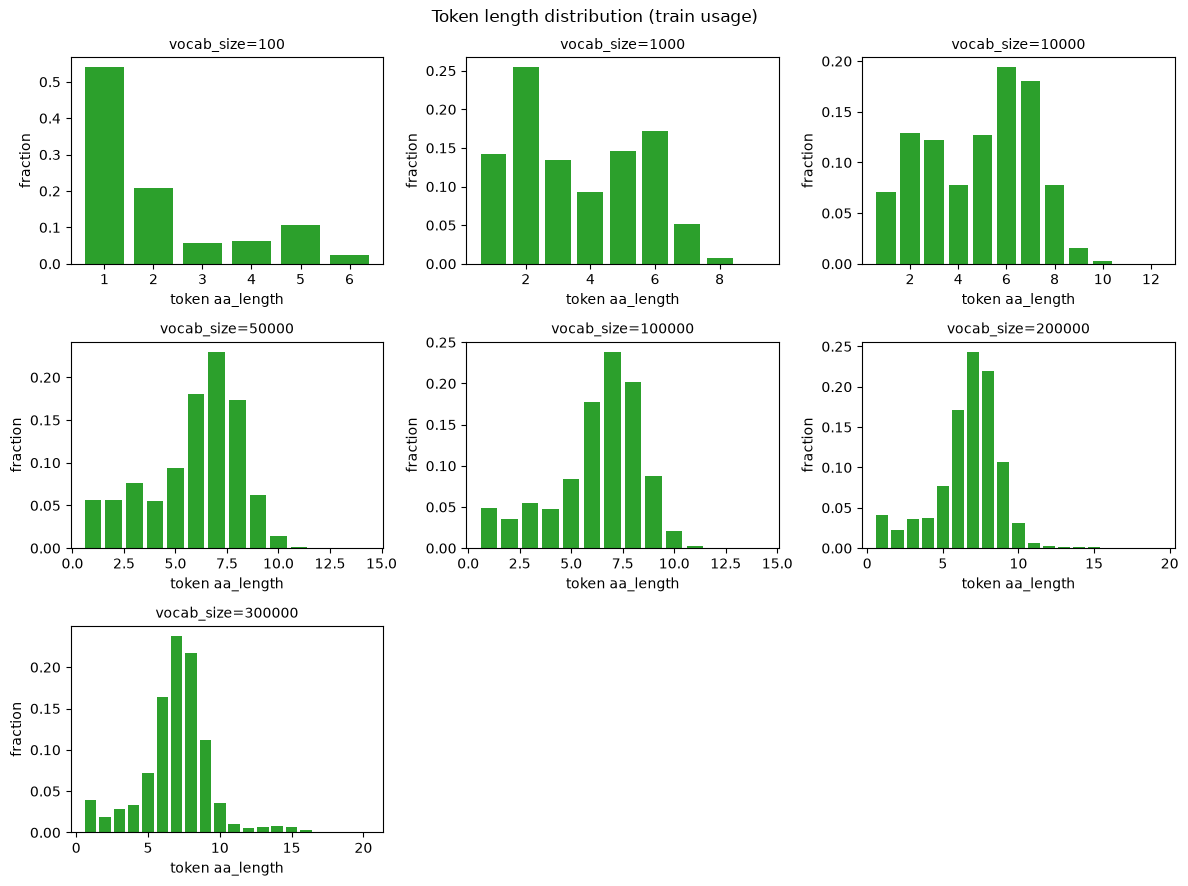

In [10]:
plot_histogram_grid(
    "token_aa_length_histogram_train", "token aa_length", "Token length distribution (train usage)",
    get_histogram=lambda vs: per_vocab_size[str(vs)]["token_aa_length_histogram_train"],
)

## 3. Alarms

In [11]:
alarm_rows = []
for vocab_size in vocab_sizes:
    for alarm_name, alarm in per_vocab_size[str(vocab_size)]["alarms"].items():
        if alarm["triggered"]:
            alarm_rows.append({"vocab_size": vocab_size, "alarm": alarm_name, "message": alarm["message"]})

if alarm_rows:
    display(pd.DataFrame(alarm_rows))
else:
    print("No alarms triggered.")

No alarms triggered.


## 4. Top tokens (train split)

Full top-n (default 50) is in the JSON; showing top `TOP_K_DISPLAY` here per list.

In [12]:
def show_top_tokens(vocab_size: int) -> None:
    entry = per_vocab_size[str(vocab_size)]
    print(f"vocab_size={vocab_size} (actual={entry['vocab_size_actual']})")

    freq_df = pd.DataFrame(entry["top_tokens_by_frequency_train"][:TOP_K_DISPLAY])
    print("\ntop by frequency:")
    display(freq_df)

    longest_df = pd.DataFrame(entry["top_longest_tokens"][:TOP_K_DISPLAY])
    print("\ntop longest tokens:")
    display(longest_df)

    non_single_df = pd.DataFrame(entry["top_non_single_amino_acid_tokens"][:TOP_K_DISPLAY])
    print("\ntop non-single-amino-acid tokens:")
    display(non_single_df)


# change this to inspect a different vocab_size from the grid
show_top_tokens(vocab_sizes[len(vocab_sizes) // 2])

vocab_size=50000 (actual=50000)

top by frequency:


,token,id,count,mean_relative_position,median_relative_position,std_relative_position,fraction_start_third,fraction_middle_third,fraction_end_third
0,##G,27,83339,0.544017,0.535714,0.088600,0.006264,0.899183,0.094554
1,##S,25,20999,0.555127,0.566667,0.084928,0.008381,0.907996,0.083623
2,##ETQYF,67,6171,0.828905,0.833333,0.022141,0.000000,0.000000,1.000000
3,##TDTQYF,76,5873,0.805695,0.812500,0.024052,0.000000,0.000000,1.000000
4,##NEQFF,59,5850,0.829440,0.833333,0.022314,0.000000,0.000000,1.000000
5,##EQYF,53,5785,0.855252,0.857143,0.018866,0.000000,0.000000,1.000000
6,##DTQYF,62,5587,0.829122,0.833333,0.021887,0.000000,0.000000,1.000000
7,##QETQYF,96,5248,0.801115,0.800000,0.023889,0.000000,0.000000,1.000000
8,##EQFF,55,4929,0.856863,0.857143,0.019761,0.000000,0.000000,1.000000
9,##YEQYF,63,4772,0.826485,0.833333,0.022154,0.000000,0.000000,1.000000



top longest tokens:


,token,id,count,aa_length
0,##PGLAGGSSYNEQFF,38092,2,14
1,##RSRPNHSGANVLTF,44569,2,14
2,##LAGGPSSYNEQFF,13942,6,13
3,##TSGGPSSYNEQFF,20968,6,13
4,##TSGGLSSYNEQFF,28237,4,13
5,##RLAGGSSYNEQFF,44438,3,13
6,##LAGGSSSYNEQFF,35627,3,13
7,##LAGGLSSYNEQFF,20962,3,13
8,##LAGGPGSYNEQFF,46644,2,13
9,##LAGGRSSYNEQFF,38509,1,13



top non-single-amino-acid tokens:


,token,id,count,aa_length
0,##ETQYF,67,6171,5
1,##TDTQYF,76,5873,6
2,##NEQFF,59,5850,5
3,##EQYF,53,5785,4
4,##DTQYF,62,5587,5
5,##QETQYF,96,5248,6
6,##EQFF,55,4929,4
7,##YEQYF,63,4772,5
8,##TQYF,50,4571,4
9,##YNEQFF,77,4144,6


In [ ]:
# uncomment to dump top tokens for every vocab_size in the grid
# for vs in vocab_sizes:
#     show_top_tokens(vs)
#     print("\n" + "=" * 80 + "\n")

## 5. Top-token position analysis

Where, relative to sequence length (0 = start, 1 = end), do the top-N most frequent tokens occur? Position is normalized per-sequence, not a fixed character-count anchor, so CDR3s of different lengths are compared on the same scale.

In [13]:
position_macro_rows = []
for vocab_size in vocab_sizes:
    macro = per_vocab_size[str(vocab_size)]["top_tokens_position_macro_composition_train"]
    position_macro_rows.append({
        "vocab_size": vocab_size,
        "start_third": macro["start_third"],
        "middle_third": macro["middle_third"],
        "end_third": macro["end_third"],
    })

position_macro_df = pd.DataFrame(position_macro_rows)
position_macro_df.style.format({"start_third": "{:.1%}", "middle_third": "{:.1%}", "end_third": "{:.1%}"})

,vocab_size,start_third,middle_third,end_third
0,100,26.4%,56.1%,17.4%
1,1000,8.9%,50.9%,40.2%
2,10000,0.7%,35.2%,64.1%
3,50000,0.3%,38.2%,61.5%
4,100000,0.2%,36.5%,63.4%
5,200000,0.2%,37.7%,62.2%
6,300000,0.2%,40.0%,59.9%


Count-weighted across the top-N frequent tokens: what fraction of their occurrences in train falls in each third of the sequence. 33.3%/33.3%/33.3% would be the uniform baseline (no positional preference).

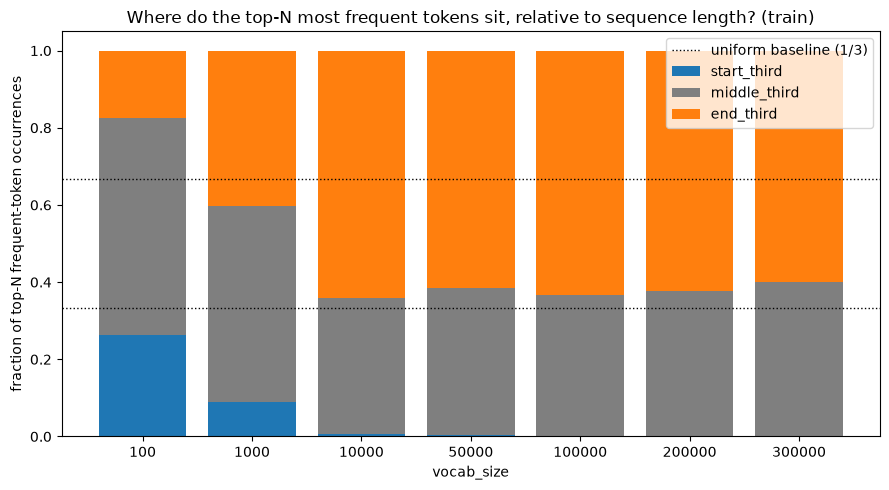

In [14]:
def plot_top_tokens_position_composition():
    fig, ax = plt.subplots(figsize=(9, 5))
    bottoms = [0.0] * len(vocab_sizes)
    region_names = ("start_third", "middle_third", "end_third")
    colors = {"start_third": "tab:blue", "middle_third": "tab:gray", "end_third": "tab:orange"}
    for region in region_names:
        values = [per_vocab_size[str(vs)]["top_tokens_position_macro_composition_train"][region] for vs in vocab_sizes]
        ax.bar([str(vs) for vs in vocab_sizes], values, bottom=bottoms, label=region, color=colors[region])
        bottoms = [b + v for b, v in zip(bottoms, values)]
    ax.axhline(1 / 3, color="black", linestyle=":", linewidth=1, label="uniform baseline (1/3)")
    ax.axhline(2 / 3, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("vocab_size"); ax.set_ylabel("fraction of top-N frequent-token occurrences")
    ax.set_title("Where do the top-N most frequent tokens sit, relative to sequence length? (train)")
    ax.legend(); fig.tight_layout(); plt.show()


plot_top_tokens_position_composition()

### Distribution of relative positions (density view)

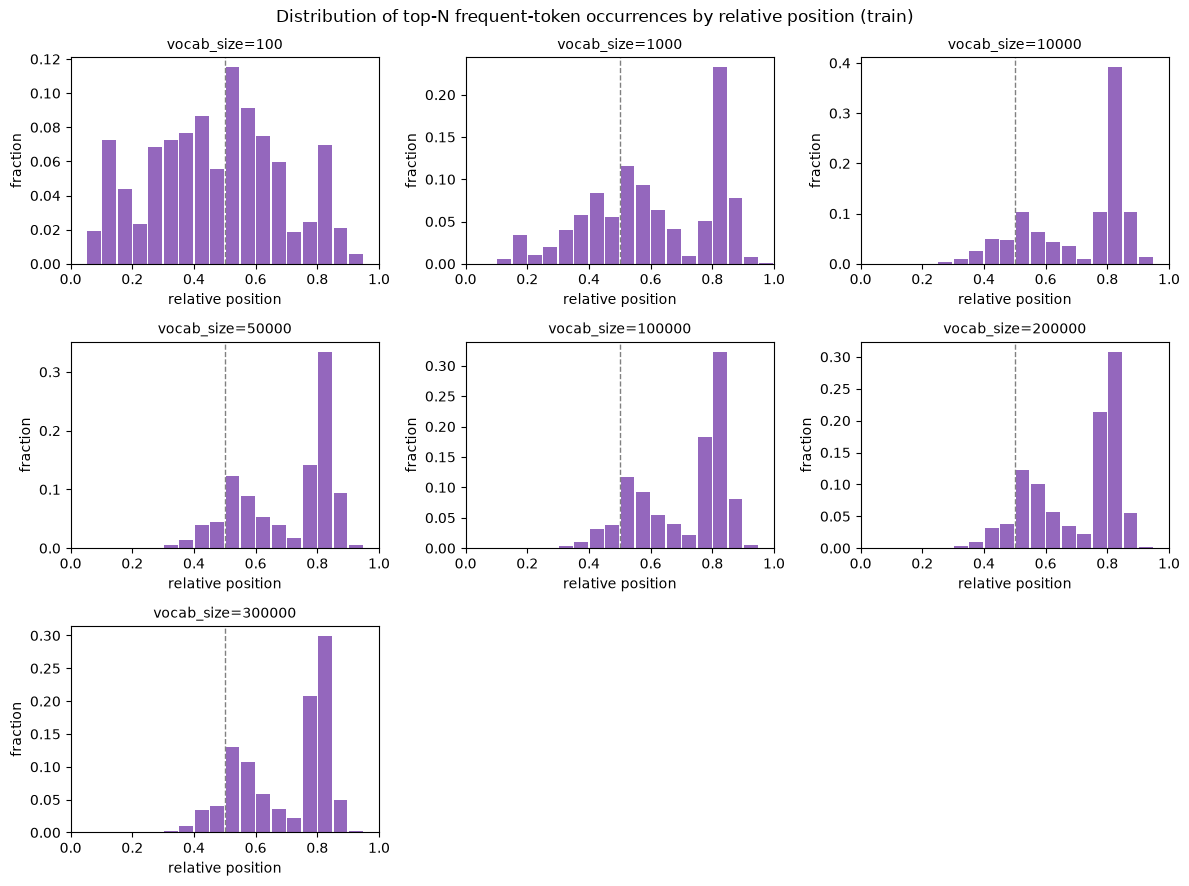

In [15]:
def plot_top_tokens_relative_position_histogram():
    ncols = 3
    nrows = math.ceil(len(vocab_sizes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), squeeze=False)
    for idx, vocab_size in enumerate(vocab_sizes):
        ax = axes[idx // ncols][idx % ncols]
        histogram = per_vocab_size[str(vocab_size)]["top_tokens_relative_position_histogram_train"]
        bin_centers = sorted(float(k) for k in histogram.keys())
        counts = [histogram[f"{c:.3f}"] for c in bin_centers]
        total = sum(counts)
        fractions = [c / total for c in counts] if total > 0 else counts
        bin_width = bin_centers[1] - bin_centers[0] if len(bin_centers) > 1 else 0.05
        ax.bar(bin_centers, fractions, width=bin_width * 0.9, color="tab:purple")
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
        ax.set_xlim(0, 1)
        ax.set_title(f"vocab_size={vocab_size}", fontsize=10)
        ax.set_xlabel("relative position"); ax.set_ylabel("fraction")
    for idx in range(len(vocab_sizes), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis("off")
    fig.suptitle("Distribution of top-N frequent-token occurrences by relative position (train)")
    fig.tight_layout(); plt.show()


plot_top_tokens_relative_position_histogram()

### Per-token relative position (mean +/- std)

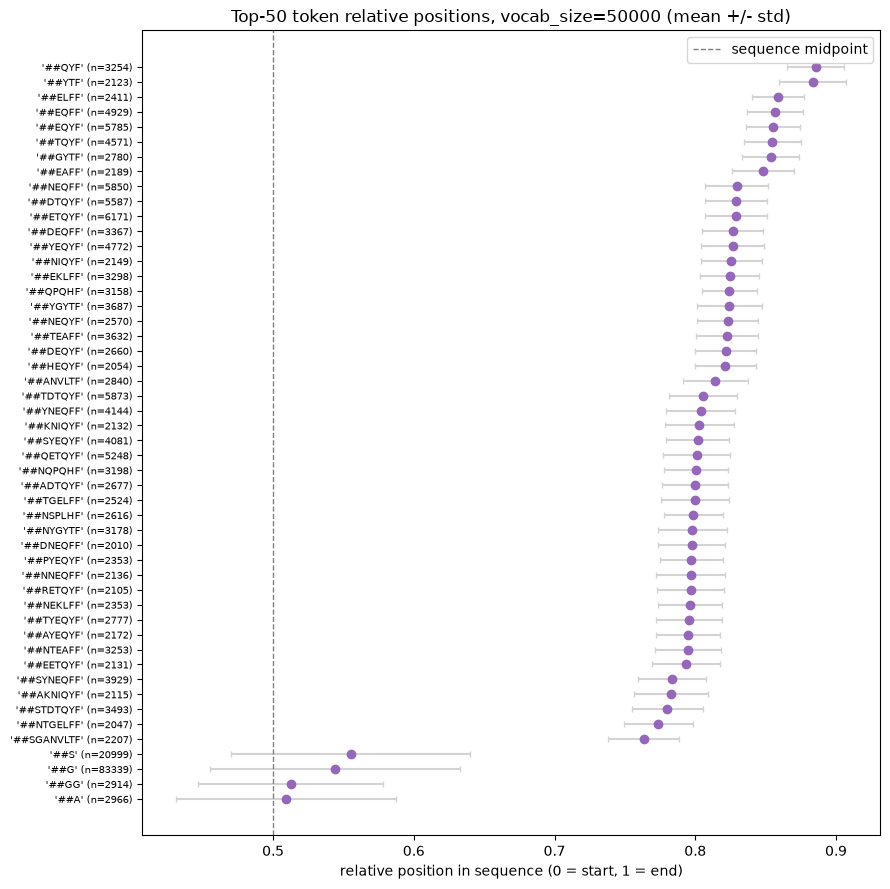

In [16]:
def plot_top_tokens_position_errorbars(vocab_size: int):
    rows = per_vocab_size[str(vocab_size)]["top_tokens_by_frequency_train"]
    sorted_rows = sorted(rows, key=lambda r: r["mean_relative_position"])
    fig, ax = plt.subplots(figsize=(9, max(4, len(sorted_rows) * 0.18)))
    y_positions = range(len(sorted_rows))
    means = [r["mean_relative_position"] for r in sorted_rows]
    stds = [r["std_relative_position"] for r in sorted_rows]
    labels = [f"{r['token']!r} (n={r['count']})" for r in sorted_rows]
    ax.errorbar(means, y_positions, xerr=stds, fmt="o", color="tab:purple", ecolor="lightgray", capsize=2)
    ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="sequence midpoint")
    ax.set_yticks(list(y_positions)); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("relative position in sequence (0 = start, 1 = end)")
    ax.set_title(f"Top-{len(sorted_rows)} token relative positions, vocab_size={vocab_size} (mean +/- std)")
    ax.legend(); fig.tight_layout(); plt.show()


# change this to inspect a different vocab_size from the grid
plot_top_tokens_position_errorbars(vocab_sizes[len(vocab_sizes) // 2])

## 6. Tokenization examples

In [17]:
examples = results.get("examples", [])
if examples:
    display(pd.DataFrame(examples))
else:
    print("No examples stored in this run.")

,original_cdr3,tokens_vocab_1000,tokens_vocab_10000
0,CAISVQDRDTEAFF,"[CAIS, ##VQ, ##DRD, ##TEAFF]","[CAISV, ##QDR, ##DTEAFF]"
1,CATSEGTAGTGYEQYF,"[CATSE, ##G, ##TAG, ##TGY, ##EQYF]","[CATSEG, ##TAG, ##TGYEQYF]"
2,CASSESRLAGANEQFF,"[CASSES, ##RLAG, ##AN, ##EQFF]","[CASSESR, ##LAGANEQFF]"
3,CASSPRQDRNTEAFF,"[CASSPR, ##QD, ##RN, ##TEAFF]","[CASSPRQ, ##DRNTEAFF]"
4,CSARDPPTVYGYTF,"[CSARDP, ##P, ##TV, ##YGYTF]","[CSARDP, ##P, ##TVYGYTF]"
5,CATSDNRGGYNEQFF,"[CATSD, ##NRG, ##GYNEQFF]","[CATSDN, ##RGGYNEQFF]"
6,CSAIRDRDGGQYF,"[CSAI, ##RDR, ##DGG, ##QYF]","[CSAIR, ##DRDG, ##G, ##QYF]"
7,CASSVPILGLSNEQFF,"[CASSV, ##PI, ##LG, ##LS, ##NEQFF]","[CASSVP, ##ILG, ##LSNEQFF]"
8,CASSPYPTSGGANQETQYF,"[CASSPY, ##P, ##TSGGA, ##NQETQYF]","[CASSPYP, ##TSGGA, ##NQETQYF]"
9,CASSKRRENEKLFF,"[CASSK, ##RR, ##E, ##NEKLFF]","[CASSKR, ##RE, ##NEKLFF]"
